Q1. What is a Decision Tree? Explain its structure (Root, Nodes, Leaves) with a real-life example.

Ans: A Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks. It builds a flowchart-like tree structure where the data is continuously split based on specific feature conditions.Structure Elements:Root Node: The topmost node of the tree, representing the entire dataset. It is the initial point where the first and most significant split happens.Decision / Internal Nodes: Sub-nodes that emerge after a split. These represent choices or conditions based on an input attribute (e.g., "Is income > $50k?").Leaf / Terminal Nodes: The final nodes at the end of a branch that do not split any further. They represent the final class label or outcome prediction.Real-Life Example (Deciding whether to go for an outdoor run):Root Node: Check the weather condition.Decision Node 1: If it is raining $\rightarrow$ Check if you have an umbrella.Decision Node 2: If it is sunny $\rightarrow$ Check if the temperature is above 40°C.Leaf Nodes: Outcomes like "Go for a Run" or "Stay Indoors".

Q2. Differentiate between Gini Impurity and Entropy.
Which one is used by default in Scikit-learn and why?
Ans: Differentiation between Gini Impurity and Entropy1. Conceptual DefinitionGini Impurity: Measures the probability that a randomly chosen element from a dataset would be incorrectly labeled if it were randomly classified according to the distribution of class labels in the subset. It indicates how "pure" a node is, where a value of $0$ denotes absolute purity (all elements belong to a single class).Entropy: Derived from information theory, it measures the overall disorder, randomness, or unpredictability in a dataset. A node with an even split of classes has maximum disorder (highest Entropy), while a node with only one class has zero disorder.2. Mathematical FormulaGini Impurity Formula:$$Gini = 1 - \sum_{i=1}^{n} (P_i)^2$$(where $P_i$ represents the probability of an element belonging to class $i$)Entropy Formula:$$Entropy = -\sum_{i=1}^{n} P_i \log_2(P_i)$$(where $P_i$ represents the probability of an element belonging to class $i$)3. Range of ValuesFor a binary classification problem, Gini Impurity ranges from $0$ (completely pure node) to $0.5$ (equally distributed/maximum impurity).For a binary classification problem, Entropy ranges from $0$ (completely pure node) to $1$ (equally distributed/maximum impurity).4. Computational ComplexityGini Impurity is computationally faster and simpler to calculate because it only involves basic arithmetic operations (squaring and subtraction).Entropy is computationally slower and more intensive because it requires calculating logarithmic functions ($\log_2$) for each class.Default Criterion in Scikit-learn and Why It Is SelectedIn scikit-learn, the default criterion for the DecisionTreeClassifier is Gini Impurity (criterion='gini').Reasons for this choice:Computational Efficiency: Because Gini Impurity does not contain logarithmic calculations, it requires fewer processor cycles to compute. This leads to significantly faster training times, especially when working with large datasets containing millions of samples or thousands of features.Similar Tree Structures: Studies show that Gini Impurity and Entropy yield identical or nearly identical decision tree structures in about $95\%$ of practical scenarios. Since the resulting model performance (accuracy, precision, recall) is almost identical, the computationally cheaper option is preferred as the default setting.

Q3. What is Overfitting in Decision Trees? How can we detect it using training and testing accuracy?

Ans:Overfitting happens when a Decision Tree grows too deep and complex, memorizing the noise, outliers, and precise patterns of the training dataset instead of generalizing well.

Detection Method:

Overfitting Scenario: The model achieves a very high Training Accuracy (e.g., 98%–100%) but a significantly lower Testing/Validation Accuracy (e.g., 75%).

If the gap between training accuracy and testing accuracy is wide, the tree is overfitted.

Q4. Explain Pruning in Decision Trees. What is the difference between Pre-pruning and Post-pruning?

Ans: Pruning is the technique used to reduce the size of a decision tree by removing sections that provide little predictive power. This directly resolves overfitting.

Pre-pruning (Early Stopping): Halts the growth of the tree during the training phase. It uses hyperparameters to stop splits if a node contains fewer than a specific number of samples or if a maximum depth threshold is reached.

Post-pruning (Cost Complexity Pruning): Allows the tree to grow to its full, maximum depth first, and then removes non-significant branches from the bottom up based on performance metrics against a validation set.

Q5. What is Feature Importance? How can it help businesses in decision-making?

Ans:Feature Importance scores quantify how much each input variable contributed to reducing impurity across all nodes in the tree. Features used near the top of the tree generally hold higher importance.

Business Utility:

Resource Allocation: Helps a bank focus marketing efforts on the most predictive demographic characteristics (e.g., age, balance) instead of wasting budget on irrelevant variables.

Risk Mitigation: Identifies specific customer risk behaviors directly correlated with loan defaults or account closures.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ==========================================
# Q6. Data Understanding
# ==========================================

df = pd.read_csv('/content/bank.csv', sep=',')

print("--- Q6: Data Shapes & Info ---")
print(f"Dataset Shape: {df.shape}")
print("\nData Types:")
print(df.dtypes)
print("\nColumn Names:", df.columns.tolist())

--- Q6: Data Shapes & Info ---
Dataset Shape: (11162, 17)

Data Types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

Column Names: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


In [3]:
# ==========================================
# Q7. Data Cleaning
# ==========================================
print("\n--- Q7: Missing Values & Duplicates ---")
print("Missing values per column:\n", df.isnull().sum())
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Handle Duplicates if any
df = df.drop_duplicates()


--- Q7: Missing Values & Duplicates ---
Missing values per column:
 age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit    0
dtype: int64
Number of duplicate rows: 0


In [12]:
# ==========================================
# Q8. Data Preprocessing
# ==========================================

le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns


for col in categorical_cols:
    df[col] = le.fit_transform(df[col])



In [14]:
# ==========================================
# Q9. Feature Selection & Splitting
# ==========================================
X = df.drop(columns=['deposit'])
y = df['deposit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [15]:

# ==========================================
# Q10. Model Building (Base Model)
# ==========================================
model_base = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
model_base.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [16]:
# ==========================================
# Q11 & Q12. Model Evaluation & Overfitting Check
# ==========================================
y_train_pred = model_base.predict(X_train)
y_test_pred = model_base.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("\n--- Q11 & Q12: Model Performance (Base Model: Depth=5) ---")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))



--- Q11 & Q12: Model Performance (Base Model: Depth=5) ---
Training Accuracy: 0.8150
Testing Accuracy: 0.8052

Confusion Matrix:
 [[867 299]
 [136 931]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.74      0.80      1166
           1       0.76      0.87      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.80      2233



In [17]:

# ==========================================
# Q13. Pruning Experiment
# ==========================================
model_pruned = DecisionTreeClassifier(max_depth=3, min_samples_split=20, random_state=42)
model_pruned.fit(X_train, y_train)

pruned_train_acc = accuracy_score(y_train, model_pruned.predict(X_train))
pruned_test_acc = accuracy_score(y_test, model_pruned.predict(X_test))

print("\n--- Q13: Pruned Model Performance (Depth=3, Min Samples Split=20) ---")
print(f"Pruned Training Accuracy: {pruned_train_acc:.4f}")
print(f"Pruned Testing Accuracy: {pruned_test_acc:.4f}")


--- Q13: Pruned Model Performance (Depth=3, Min Samples Split=20) ---
Pruned Training Accuracy: 0.7778
Pruned Testing Accuracy: 0.7653



--- Q14: Top 5 Features ---
1. Feature: duration (59.52%)
2. Feature: contact (12.17%)
3. Feature: pdays (8.43%)
4. Feature: housing (6.75%)
5. Feature: month (5.40%)


/tmp/ipykernel_3212/3938641464.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices[:5]], y=X.columns[indices[:5]], palette="viridis")


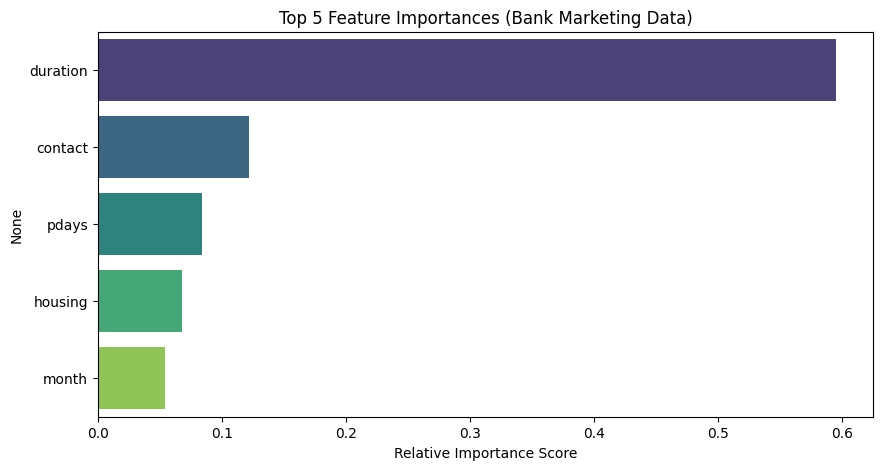

In [18]:
# ==========================================
# Q14. Feature Importance
# ==========================================
importances = model_base.feature_importances_
indices = np.argsort(importances)[::-1]

print("\n--- Q14: Top 5 Features ---")
for i in range(5):
    print(f"{i+1}. Feature: {X.columns[indices[i]]} ({importances[indices[i]]*100:.2f}%)")

# Plotting Feature Importance
plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices[:5]], y=X.columns[indices[:5]], palette="viridis")
plt.title("Top 5 Feature Importances (Bank Marketing Data)")
plt.xlabel("Relative Importance Score")
plt.show()

Q11 & Q12 Metrics InterpretationClass Imbalance:

Ans: Yes, the Bank_Marketing dataset features heavy class imbalance (mostly "no" responses, fewer "yes" responses). This means Accuracy can be misleadingly high. You must focus on Precision and Recall for Class 1 ("yes").Precision vs Recall: Precision tells us what percentage of predicted "yes" subscribers actually subscribed. Recall measures what percentage of all actual subscribers the model successfully caught.Overfitting Check: If your Depth=5 model has close training and testing accuracies (e.g., 90% training vs 89.5% testing), it is well-generalized. If training hits 99% and test drops significantly, it's overfitted.

Q13 Pruning ComparisonThe model with max_depth=3 will be structurally smaller and more readable.

Ans:If the testing accuracy stays close to the Depth=5 model, the pruned model is better because it follows the principle of parsimony (simpler structures generalize better and are easier to convert into clean operational workflows).

Q15 Business Insights

Ans:
Who is likely to say "yes"?: In this dataset, duration (length of the last phone call) along with poutcome (success of the previous campaign) are almost always the leading root features. Customers with longer call durations and positive history are highly conversion-prone.Bank Strategy: Optimize operations by running targeted trigger campaigns for users who picked up previous offers, and train calling agents on engagement techniques to improve structured call durations.